Credit Card Fraud Detection using Decision Tree
Dataset: ULB Machine Learning Group - Credit Card Fraud Detection

Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

---

### Objective

The goal of this project is to detect fraudulent credit card transactions using a Decision Tree classifier.

---

### Key Challenges

* Highly imbalanced dataset (very few fraud cases)
* Accuracy is misleading due to imbalance
* Need to maximize fraud detection (recall)
* Risk of overfitting in Decision Trees

---

### Approach

* Use full dataset (no undersampling)
* Apply cost-sensitive learning (`class_weight='balanced'`)
* Control overfitting using tree parameters (max_depth, min_samples_split, min_samples_leaf)
* Perform hyperparameter tuning using GridSearchCV
* Evaluate model using multiple metrics (Precision, Recall, F1-score, Confusion Matrix)


In [4]:
# ============================================
# Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

Dataset Description
The dataset consists of real-world credit card transactions. The features (V1–V28) are anonymized numerical variables obtained through PCA transformation.

Key characteristics:

Total transactions: 284,807
Fraudulent transactions: 492

Highly imbalanced dataset (fraud < 1%)
Due to the imbalance, traditional evaluation metrics such as accuracy may not reflect the true performance of the model.

In [6]:
# ============================================
# Load dataset
# ============================================

df = pd.read_csv('creditcard.csv.gz')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dataset Overview

This step checks:

Number of rows and columns

Data types

Missing values

This ensures the dataset is ready for analysis.

In [7]:
# ============================================
# Dataset information
# ============================================

print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

Class Imbalance

The dataset is highly imbalanced, with the majority of transactions being normal.

**This creates a major challenge:**

A model can achieve very high accuracy by predicting all transactions as normal

However, such a model would fail to detect fraud

Therefore, accuracy alone is not a reliable metric for evaluating performance in this problem.


In [8]:
# ============================================
# Check class imbalance
# ============================================

class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


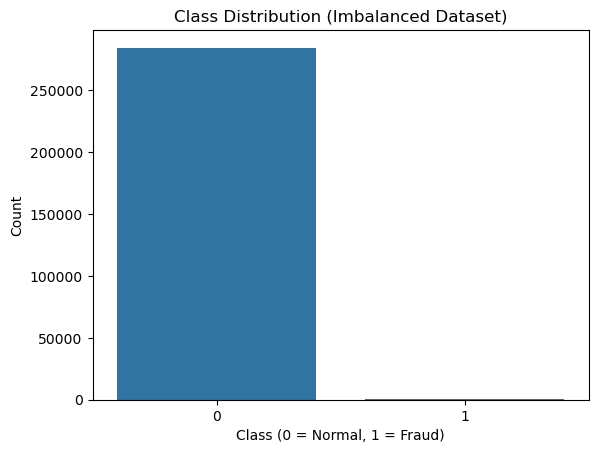

In [9]:
# ============================================
# Visualize class imbalance
# ============================================

plt.figure()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution (Imbalanced Dataset)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

**Feature and Target Separation**

X → input features

y → target variable (fraud or normal)

In [10]:
# ============================================
# Split features and target
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

**Train-Test Split**

The dataset is split into:

    Training data (to train the model)

    Testing data (to evaluate the model)
    
This ensures fair evaluation.

In [11]:
# ============================================
# Train-test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (227845, 30)
Testing shape: (56962, 30)


**Baseline Model**

A Decision Tree classifier was first trained using default parameters.

Purpose:

   *To establish a reference point for performance
   
   *To observe the effect of class imbalance on the model

The baseline model does not handle imbalance or control overfitting.

In [12]:
# ============================================
# Baseline Decision Tree
# ============================================

baseline_model = DecisionTreeClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

print("\nBaseline Classification Report:\n",
      classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.9990519995786665

Baseline Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.80      0.74        98

    accuracy                           1.00     56962
   macro avg       0.85      0.90      0.87     56962
weighted avg       1.00      1.00      1.00     56962



**Improved Model (Manual Tuning)**

The Decision Tree model is improved by adjusting hyperparameters:

   *max_depth limits the depth of the tree to reduce overfitting

   *min_samples_split prevents unnecessary splits

   *min_samples_leaf ensures stable leaf nodes
  
*class_weight='balanced' handles class imbalance

These improvements help the model generalize better and detect fraud more effectively.

In [13]:
# ============================================
# Improved Decision Tree
# ============================================

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'
